In [1]:
# Cell 0 — Imports & setup
import os
from pathlib import Path

import pandas as pd
import numpy as np
import duckdb
import cv2
import matplotlib.pyplot as plt
from dotenv import load_dotenv

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", None)

load_dotenv()  # optional


True

In [2]:
# Cell 1 — Connect & inspect DB (DuckDB only; no fallbacks)
DB_PATH = "../data/mydb2024-25.duckdb"
con = duckdb.connect(database=DB_PATH, read_only=False)

print("Tables in the database:")
for (t,) in con.execute("SHOW TABLES").fetchall():
    print(" -", t)


Tables in the database:
 - fixtures
 - fixtures_enhanced
 - fixtures_session_sync_log
 - kinexon_events_detected
 - kinexon_events_detected_enriched
 - kinexon_positions
 - kinexon_throwpoint_refined
 - match_events
 - players
 - teams
 - vw_kinexon_events_detected_with_matchid


In [3]:
# Cell 2 — fixtures_enhanced joined with fixtures to bring session_id
df_fixtures = con.execute("""
    SELECT 
        fe.*, 
        f.session_id
    FROM fixtures_enhanced AS fe
    LEFT JOIN fixtures AS f
      ON fe.fixtureId = f.fixtureId
""").df()

print("SPORTRADAR: Fixtures data (with session_id):")
display(df_fixtures.head())


SPORTRADAR: Fixtures data (with session_id):


,fixtureId,seasonId,fixtureNumber,nameLocal,nameLatin,startTimeLocal,startTimeUTC,roundNumber,externalId,entityId_home,entityId_away,name_team_home,name_team_away,score_home,score_away,resultPlace_home,resultPlace_away,standing_home,standing_away,wins_home,draws_home,losses_home,pts_against_home,wins_away,draws_away,losses_away,pts_against_away,session_id
0,ccdbc62f-4373-11ef-8506-0f9723377f57,cabcf509-4373-11ef-a370-9d3c1e90234a,1,TSV Hannover-Burgdorf vs. VfL Gummersbach,<NA>,2024-09-05T19:00:00,2024-09-05 17:00:00,1,57919,fea93a14-3952-11ef-a7e0-af5c55c3771d,fe911367-3952-11ef-9131-af5c55c3771d,TSV Hannover-Burgdorf,VfL Gummersbach,28,32,2,1,18,1,0,0,1,2,1,0,0,0,2564
1,cee2c85c-4373-11ef-94e2-cd77cb69a9df,cabcf509-4373-11ef-a370-9d3c1e90234a,2,TBV Lemgo Lippe vs. MT Melsungen,<NA>,2024-09-05T19:00:00,2024-09-05 17:00:00,1,57920,fe99a935-3952-11ef-9dd4-af5c55c3771d,feb41b46-3952-11ef-9df6-af5c55c3771d,TBV Lemgo Lippe,MT Melsungen,20,28,2,1,18,1,0,0,1,2,1,0,0,0,2573
2,d0f835ea-4373-11ef-a915-811a78587cbc,cabcf509-4373-11ef-a370-9d3c1e90234a,3,Rhein-Neckar Löwen vs. THW Kiel,<NA>,2024-09-05T20:30:00,2024-09-05 18:30:00,1,57921,fe80598a-3952-11ef-914c-af5c55c3771d,febf038e-3952-11ef-b7c2-af5c55c3771d,Rhein-Neckar Löwen,THW Kiel,32,27,1,2,2,17,1,0,0,0,0,0,1,2,2578
3,d1f5d36c-4373-11ef-ada8-811a78587cbc,cabcf509-4373-11ef-a370-9d3c1e90234a,4,FRISCH AUF! Göppingen vs. Handball Sport Verein Hamburg,<NA>,2024-09-06T19:00:00,2024-09-06 17:00:00,1,57922,fea4237d-3952-11ef-9fcd-af5c55c3771d,0045fbc4-3953-11ef-a217-af5c55c3771d,FRISCH AUF! Göppingen,Handball Sport Verein Hamburg,25,25,1,1,4,5,0,1,0,1,0,1,0,1,2577
4,d3e126de-4373-11ef-9661-2f970b50aee5,cabcf509-4373-11ef-a370-9d3c1e90234a,5,SG Flensburg-Handewitt vs. HC Erlangen,<NA>,2024-09-06T20:00:00,2024-09-06 18:00:00,1,57923,fe88f93b-3952-11ef-aa5d-af5c55c3771d,fe8d1885-3952-11ef-9130-af5c55c3771d,SG Flensburg-Handewitt,HC Erlangen,42,28,1,2,1,18,1,0,0,0,0,0,1,2,2582


In [4]:
# Cell 4 — Pick a sample fixture that exists in Kinexon AND Sportradar
# Strategy: take first fixtureId present in kinexon_positions AND in fixtures_enhanced
sample_row = con.execute("""
    WITH kin AS (
        SELECT DISTINCT fixture_id
        FROM kinexon_positions
        WHERE fixture_id IS NOT NULL
    )
    SELECT fe.fixtureId, f.session_id
    FROM fixtures_enhanced fe
    LEFT JOIN fixtures f ON f.fixtureId = fe.fixtureId
    JOIN kin ON kin.fixture_id = fe.fixtureId
    LIMIT 1
""").df()

if sample_row.empty:
    raise RuntimeError("No overlapping fixture between Kinexon and Sportradar found.")

sample_fixture_id = sample_row.loc[0, "fixtureId"]
sample_session_id = sample_row.loc[0, "session_id"]

print(f"Sample fixtureId: {sample_fixture_id}")
print(f"Sample session_id: {sample_session_id}")
# print info about game col competitor
df_sample_fixture = df_fixtures[df_fixtures['fixtureId'] == sample_fixture_id]
print("Fixture info:")
display(df_sample_fixture)
# show sample row from kinexon_positions for sample_session_id
df_kinexon_positions = con.execute("""
    SELECT *
    FROM kinexon_positions
    WHERE session_id = ?
""", [int(sample_session_id)]).df()
print("KINEXON: Positions sample:")
display(df_kinexon_positions.head())


Sample fixtureId: da143ecf-4373-11ef-b622-f97fb227f741
Sample session_id: 2579
Fixture info:


,fixtureId,seasonId,fixtureNumber,nameLocal,nameLatin,startTimeLocal,startTimeUTC,roundNumber,externalId,entityId_home,entityId_away,name_team_home,name_team_away,score_home,score_away,resultPlace_home,resultPlace_away,standing_home,standing_away,wins_home,draws_home,losses_home,pts_against_home,wins_away,draws_away,losses_away,pts_against_away,session_id
7,da143ecf-4373-11ef-b622-f97fb227f741,cabcf509-4373-11ef-a370-9d3c1e90234a,8,SC DHfK Leipzig vs. TVB Stuttgart,<NA>,2024-09-08T15:00:00,2024-09-08 13:00:00,1,57926,feace61d-3952-11ef-ae23-af5c55c3771d,febb3114-3952-11ef-b6f7-af5c55c3771d,SC DHfK Leipzig,TVB Stuttgart,33,24,1,2,2,17,1,0,0,0,0,0,1,2,2579


KINEXON: Positions sample:


,ts in ms,formatted local time,sensor id,mapped id,number,full name,league id,group id,group name,x in m,y in m,speed in m/s,direction of movement in deg,acceleration in m/s2,total distance in m,metabolic power in W/kg,acceleration load,Unnamed: 17,session_id,fixture_id
0,1725800446950,08.09.2024 15:00:46.950,45779,1736,24,Moritz Preuss,592112,1,SC DHFK Leipzig,20.012,11.122,0.495,NaN,0.555,0.0,2.488,0.491,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
1,1725800446950,08.09.2024 15:00:46.950,45185,1462,73,Viggó Kristjánsson,1291920,1,SC DHFK Leipzig,19.577,2.368,0.428,-74.906,0.193,0.0,1.632,0.587,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
2,1725800446950,08.09.2024 15:00:46.950,45790,1859,18,Staffan Peter,2313429,1,SC DHFK Leipzig,19.742,1.132,0.282,NaN,0.063,0.0,1.052,0.320,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
3,1725800446950,08.09.2024 15:00:46.950,45094,1857,11,Lukas Binder,868728,1,SC DHFK Leipzig,19.192,19.899,0.431,NaN,0.457,0.0,1.986,0.671,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
4,1725800446950,08.09.2024 15:00:46.950,322279,1630,13,Matej Klima,1633198,1,SC DHFK Leipzig,18.044,18.199,0.362,NaN,0.491,0.0,1.882,0.355,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741


In [5]:
# Cell 5 — Pull match events for sample fixture (parameterized)
df_match_events = con.execute("""
    SELECT *
    FROM match_events
    WHERE fixtureId = ?
""", [sample_fixture_id]).df()

print(f"SPORTRADAR: Match events for fixtureId {sample_fixture_id}:")
display(df_match_events)


SPORTRADAR: Match events for fixtureId da143ecf-4373-11ef-b622-f97fb227f741:


,fixtureId,class,eventId,eventTime,eventType,subType,attendance,entityId,personId,bib,name,position,scores,periodId,playId,clock,success,x,y,attackType,goalKeeperId,location,failureReason,emptyNet,teamName,personName,goalkeeperName,session_id
0,da143ecf-4373-11ef-b622-f97fb227f741,setup,a8c18c50-6df0-11ef-90d5-e7e599d57524,2024-09-08T12:05:28.869Z,fixture,post,3692.0,None,None,None,None,None,<NA>,NaN,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,None,None,None,2579
1,da143ecf-4373-11ef-b622-f97fb227f741,setup,ff1847d0-8013-11ef-981c-432b7578a344,2024-09-08T12:05:28.879Z,person,None,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,7497dd59-3954-11ef-89aa-bdf3bafad9bd,1,Domenico Ebner,G,<NA>,NaN,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,SC DHfK Leipzig,Domenico Ebner,None,2579
2,da143ecf-4373-11ef-b622-f97fb227f741,setup,ff1847d1-8013-11ef-981c-432b7578a344,2024-09-08T12:05:28.889Z,person,None,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,0c0ae2fc-3955-11ef-9707-791010fc8985,4,Andri Mar Runarsson,CB,<NA>,NaN,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,SC DHfK Leipzig,Andri Mar Runarsson,None,2579
3,da143ecf-4373-11ef-b622-f97fb227f741,setup,ff1847d2-8013-11ef-981c-432b7578a344,2024-09-08T12:05:28.899Z,person,None,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,45e45e6e-3953-11ef-9fa9-855e48b08f9c,5,Simon Ernst,CB,<NA>,NaN,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,SC DHfK Leipzig,Simon Ernst,None,2579
4,da143ecf-4373-11ef-b622-f97fb227f741,setup,ff1847d3-8013-11ef-981c-432b7578a344,2024-09-08T12:05:28.909Z,person,None,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,7355d995-3954-11ef-9029-bdf3bafad9bd,7,Luca Witzke,CB,<NA>,NaN,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,SC DHfK Leipzig,Luca Witzke,None,2579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,da143ecf-4373-11ef-b622-f97fb227f741,clock,01831080-6df0-11ef-90d5-e7e599d57524,2024-09-08T14:38:25.681Z,main,stop,NaN,None,None,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 33, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 24}",2.0,None,PT30M0S,<NA>,NaN,NaN,None,None,None,None,<NA>,None,None,None,2579
524,da143ecf-4373-11ef-b622-f97fb227f741,sport,01831081-6df0-11ef-90d5-e7e599d57524,2024-09-08T14:38:25.691Z,period,end,NaN,None,None,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 33, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 24}",2.0,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,None,None,None,2579
525,da143ecf-4373-11ef-b622-f97fb227f741,sport,0395c3e0-6df0-11ef-90d5-e7e599d57524,2024-09-08T14:38:29.150Z,period,confirmed,NaN,None,None,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 33, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 24}",2.0,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,None,None,None,2579
526,da143ecf-4373-11ef-b622-f97fb227f741,sport,1fbc7dc0-6df0-11ef-90d5-e7e599d57524,2024-09-08T14:39:16.380Z,fixture,end,NaN,None,None,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 33, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 24}",2.0,None,None,<NA>,NaN,NaN,None,None,None,None,<NA>,None,None,None,2579


In [6]:
# Cell 6 — Kinexon rows for this session (parameterized)
df_kinexon_positions = con.execute("""
    SELECT *
    FROM kinexon_positions
    WHERE session_id = ?
""", [int(sample_session_id)]).df()

print("KINEXON: Positions sample:")
display(df_kinexon_positions.head())

# Parse times
df_kinexon_positions = df_kinexon_positions.copy()
df_kinexon_positions["ts"] = pd.to_datetime(
    df_kinexon_positions["ts in ms"], unit="ms", utc=True, errors="coerce"
)


KINEXON: Positions sample:


,ts in ms,formatted local time,sensor id,mapped id,number,full name,league id,group id,group name,x in m,y in m,speed in m/s,direction of movement in deg,acceleration in m/s2,total distance in m,metabolic power in W/kg,acceleration load,Unnamed: 17,session_id,fixture_id
0,1725800446950,08.09.2024 15:00:46.950,45779,1736,24,Moritz Preuss,592112,1,SC DHFK Leipzig,20.012,11.122,0.495,NaN,0.555,0.0,2.488,0.491,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
1,1725800446950,08.09.2024 15:00:46.950,45185,1462,73,Viggó Kristjánsson,1291920,1,SC DHFK Leipzig,19.577,2.368,0.428,-74.906,0.193,0.0,1.632,0.587,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
2,1725800446950,08.09.2024 15:00:46.950,45790,1859,18,Staffan Peter,2313429,1,SC DHFK Leipzig,19.742,1.132,0.282,NaN,0.063,0.0,1.052,0.320,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
3,1725800446950,08.09.2024 15:00:46.950,45094,1857,11,Lukas Binder,868728,1,SC DHFK Leipzig,19.192,19.899,0.431,NaN,0.457,0.0,1.986,0.671,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741
4,1725800446950,08.09.2024 15:00:46.950,322279,1630,13,Matej Klima,1633198,1,SC DHFK Leipzig,18.044,18.199,0.362,NaN,0.491,0.0,1.882,0.355,NaN,2579,da143ecf-4373-11ef-b622-f97fb227f741


In [7]:
# Cell 6a — Map *per-player* Kinexon "league id" (by name) → players.league_id (exact+fuzzy), with diagnostics

from difflib import get_close_matches, SequenceMatcher
import pandas as pd

def _norm(s: str) -> str:
    if s is None:
        return ""
    return (
        str(s)
        .strip()
        .lower()
        .replace("-", " ")
        .replace(".", " ")
        .replace(",", " ")
        .replace("  ", " ")
    )

def _similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

# 1) SR players in fixture (use Local; keep Latin for fallback/diagnostics)
df_players_in_fixture = con.execute("""
    SELECT DISTINCT p.personId, p.nameFullLocal, p.nameFullLatin
    FROM players AS p
    JOIN match_events AS me ON p.personId = me.personId
    WHERE me.fixtureId = ?
""", [sample_fixture_id]).df()
print(f"SPORTRADAR: players in fixture {sample_fixture_id}: {len(df_players_in_fixture)}")
display(df_players_in_fixture.head())

# 2) KINEXON per-name player "league id" (NOT a session-wide value!)
#    Aggregate all rows per 'full name' and take the MODE of 'league id' as the per-player id.
kx = df_kinexon_positions[["full name", "league id"]].dropna().copy()
kx["league id"] = kx["league id"].astype(str)

# unique ids per name (diagnostics)
kx_ids_per_name = (
    kx.groupby("full name")["league id"]
      .nunique()
      .rename("unique_league_ids_per_name")
      .reset_index()
)

# choose mode league id per name
def _mode_or_first(s: pd.Series) -> str:
    s = s.dropna()
    if s.empty:
        return None
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

kx_per_name = (
    kx.groupby("full name")["league id"]
      .agg(_mode_or_first)
      .reset_index()
      .rename(columns={"full name": "full_name_kinexon", "league id": "kin_league_id"})
)

# attach diagnostics for multiple ids
kx_per_name = kx_per_name.merge(kx_ids_per_name, left_on="full_name_kinexon", right_on="full name", how="left")
kx_per_name.drop(columns=["full name"], inplace=True)

# normalized key for matching
kx_per_name["norm_key"] = kx_per_name["full_name_kinexon"].map(_norm)

print(f"KINEXON: distinct names: {len(kx_per_name)}")
print("KINEXON per-name (sample):")
display(kx_per_name.head())

# 3) Build search dictionaries
kin_map_key_to_name = dict(zip(kx_per_name["norm_key"], kx_per_name["full_name_kinexon"]))
kin_map_key_to_league = dict(zip(kx_per_name["norm_key"], kx_per_name["kin_league_id"]))
kin_keys = list(kin_map_key_to_name.keys())

# 4) Exact + fuzzy name matching (try Local first, then Latin)
rows_exact, rows_fuzzy = [], []

for _, r in df_players_in_fixture.iterrows():
    pid = r["personId"]
    sr_local = str(r["nameFullLocal"])
    sr_latin = str(r["nameFullLatin"])

    # try local
    key_local = _norm(sr_local)
    # fallback latin if local is empty
    key_fallback = _norm(sr_latin) if not key_local else key_local

    # exact on preferred key, else exact on fallback if different
    matched_key = None
    if key_local in kin_keys:
        matched_key = key_local
    elif key_fallback in kin_keys:
        matched_key = key_fallback

    if matched_key:
        rows_exact.append((
            pid, sr_local, sr_latin,
            kin_map_key_to_name[matched_key],
            kin_map_key_to_league[matched_key],
            1.0
        ))
        continue

    # fuzzy on preferred key space
    cand = get_close_matches(key_fallback, kin_keys, n=1, cutoff=0.84)
    if cand:
        best_key = cand[0]
        score = _similarity(key_fallback, best_key)
        rows_fuzzy.append((
            pid, sr_local, sr_latin,
            kin_map_key_to_name[best_key],
            kin_map_key_to_league[best_key],
            score
        ))

print(f"Exact matches: {len(rows_exact)} | Fuzzy matches: {len(rows_fuzzy)}")

# 5) Consolidate matches to write
df_match = pd.DataFrame(
    rows_exact + rows_fuzzy,
    columns=["personId", "nameFullLocal_sportradar", "nameFullLatin_sportradar",
             "full_name_kinexon", "league_id", "similarity"]
)
print("Preview of per-player Kinexon IDs to write into players.league_id:")
display(df_match.sort_values("similarity", ascending=False).head(20))

# 6) Update players.league_id (per-player!)
con.execute("""ALTER TABLE players ADD COLUMN IF NOT EXISTS league_id TEXT""")
con.register("tmp_player_league_map", df_match[["personId", "league_id"]])
con.execute("""
    UPDATE players AS p
    SET league_id = tlm.league_id
    FROM tmp_player_league_map AS tlm
    WHERE p.personId = tlm.personId
""")
con.unregister("tmp_player_league_map")

print(f"✅ Updated players.league_id for {len(df_match)} players (fixtureId={sample_fixture_id}).")

# 7) DIAGNOSTICS — Unmatched SR players
matched_ids = set(df_match["personId"].tolist())
df_unmatched_sr = df_players_in_fixture[~df_players_in_fixture["personId"].isin(matched_ids)].copy()
df_unmatched_sr["nameFullLocal_norm"] = df_unmatched_sr["nameFullLocal"].map(_norm)
df_unmatched_sr["nameFullLatin_norm"] = df_unmatched_sr["nameFullLatin"].map(_norm)
print(f"❗ Unmatched Sportradar players in fixture {sample_fixture_id}: {len(df_unmatched_sr)}")
display(df_unmatched_sr[["personId", "nameFullLocal", "nameFullLatin"]])

# Suggestions for unmatched SR (top-3 Kinexon candidates)
def _top_k(sr_norm: str, k: int = 3):
    if not sr_norm:
        return []
    scored = [(_similarity(sr_norm, kk), kin_map_key_to_name[kk], kin_map_key_to_league[kk]) for kk in kin_keys]
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:k]

suggest = []
for _, rr in df_unmatched_sr.iterrows():
    sr_norm = rr["nameFullLocal_norm"] or rr["nameFullLatin_norm"]
    top = _top_k(sr_norm, 3)
    suggest.append({
        "personId": rr["personId"],
        "SR_nameLocal": rr["nameFullLocal"],
        "SR_nameLatin": rr["nameFullLatin"],
        "cand_1": f"{top[0][1]} [id={top[0][2]}] ({top[0][0]:.2f})" if len(top) > 0 else None,
        "cand_2": f"{top[1][1]} [id={top[1][2]}] ({top[1][0]:.2f})" if len(top) > 1 else None,
        "cand_3": f"{top[2][1]} [id={top[2][2]}] ({top[2][0]:.2f})" if len(top) > 2 else None,
    })
df_unmatched_suggestions = pd.DataFrame(suggest)
print("🔎 Suggestions for unmatched SR players (Kinexon name → player league id):")
display(df_unmatched_suggestions.head(30))

# 8) DIAGNOSTICS — Kinexon names with multiple different IDs (ambiguity)
multi_id_names = kx_ids_per_name.query("unique_league_ids_per_name > 1").sort_values("unique_league_ids_per_name", ascending=False)
if not multi_id_names.empty:
    print("⚠️ Kinexon 'full name' appears with multiple different 'league id' values (mode chosen):")
    display(
        multi_id_names.merge(kx, left_on="full name", right_on="full name", how="left")
                      .sort_values(["unique_league_ids_per_name", "full name"], ascending=[False, True])
    )

# 9) Snapshot of this fixture after update
post = con.execute("""
    SELECT DISTINCT p.personId, p.nameFullLocal, p.nameFullLatin, p.league_id
    FROM players p
    JOIN match_events me ON me.personId = p.personId
    WHERE me.fixtureId = ?
    ORDER BY p.nameFullLocal
    LIMIT 50
""", [sample_fixture_id]).df()
print("Post-update snapshot (first 50 for this fixture):")
display(post)



SPORTRADAR: players in fixture da143ecf-4373-11ef-b622-f97fb227f741: 31


,personId,nameFullLocal,nameFullLatin
0,45e45e6e-3953-11ef-9fa9-855e48b08f9c,Simon Ernst,Simon Ernst
1,73a9ee2d-3954-11ef-83c4-bdf3bafad9bd,Samuel Röthlisberger,Samuel Röthlisberger
2,e7ffe003-3954-11ef-86ab-0119270b4993,Kristian Sæverås,Kristian Sæverås
3,f808165f-4a6e-11ef-ab68-716a965e99e1,Friedrich Schmitt,Friedrich Schmitt
4,503be211-3953-11ef-8766-a9530db97767,Franz Semper,Franz Semper


KINEXON: distinct names: 32
KINEXON per-name (sample):


,full_name_kinexon,kin_league_id,unique_league_ids_per_name,norm_key
0,Achilleas Toskas,2187826,1,achilleas toskas
1,Andri Mar Runarsson,2183644,1,andri mar runarsson
2,Ante Ivankovic,1560420,1,ante ivankovic
3,Ball1 Ball,LeipBall1,1,ball1 ball
4,Ball2 Ball,LeipBall2,1,ball2 ball


Exact matches: 29 | Fuzzy matches: 1
Preview of per-player Kinexon IDs to write into players.league_id:


...

,personId,nameFullLocal,nameFullLatin
28,38131d18-3955-11ef-ba40-bfbfc9e17c09,Nils Greilich,Nils Greilich


🔎 Suggestions for unmatched SR players (Kinexon name → player league id):


,personId,SR_nameLocal,SR_nameLatin,cand_1,cand_2,cand_3
0,38131d18-3955-11ef-ba40-bfbfc9e17c09,Nils Greilich,Nils Greilich,Lucas Krzikalla [id=868722] (0.43),Nico Schöttle [id=2188008] (0.38),Daniel Fernandez Jimenez [id=1872158] (0.38)


Post-update snapshot (first 50 for this fixture):


,personId,nameFullLocal,nameFullLatin,league_id
0,d4df0d7f-3e96-11ef-ac06-69f3493fbb6d,Achilleas Toskas,Achilleas Toskas,2187826
1,0c0ae2fc-3955-11ef-9707-791010fc8985,Andri Mar Runarsson,Andri Mar Runarsson,2183644
2,2041acfc-3956-11ef-aa51-f300d8784a69,Ante Ivankovic,Ante Ivankovic,1560420
3,6b0c9b8d-54c9-11ef-8b34-e743f9f37b06,Bruno Reguart Massana,Bruno Reguart Massana,2188026
4,f6b799a0-3955-11ef-a2cf-e79bf7b1fa4b,Daniel Fernandez Jimenez,Daniel Fernandez Jimenez,1872158
5,7497dd59-3954-11ef-89aa-bdf3bafad9bd,Domenico Ebner,Domenico Ebner,1027241
6,503be211-3953-11ef-8766-a9530db97767,Franz Semper,Franz Semper,869388
7,f808165f-4a6e-11ef-ab68-716a965e99e1,Friedrich Schmitt,Friedrich Schmitt,2422719
8,69551a95-54c9-11ef-ab9f-e72f33e8c319,Gianfranco Pribetić,Gianfranco Pribetić,1560432
9,f817549f-3955-11ef-8ef9-e79bf7b1fa4b,Jonas Truchanovicius,Jonas Truchanovicius,1290170


In [8]:
# Cell 7 — Filter to sport/goal events, parse & sort
df_goals = (
    df_match_events
    .loc[(df_match_events["class"] == "sport") & (df_match_events["eventType"] == "goal")]
    .copy()
)

df_goals["eventTime"] = pd.to_datetime(df_goals["eventTime"], utc=True, errors="coerce")

df_kinexon_positions = df_kinexon_positions.sort_values("ts")
df_goals = df_goals.sort_values("eventTime")

print("Goals in this fixture:")
display(df_goals)

# join league id from players to goals
df_goals = df_goals.merge(
    con.execute("SELECT personId, league_id AS person_league_id FROM players").df(),
    on="personId",
    how="left"
)
df_goals = df_goals.merge(
    con.execute("SELECT personId as goalKeeperId, league_id AS goalkeeper_league_id FROM players").df(),
    on="goalKeeperId",
    how="left"
)

display(df_goals)



Goals in this fixture:


,fixtureId,class,eventId,eventTime,eventType,subType,attendance,entityId,personId,bib,name,position,scores,periodId,playId,clock,success,x,y,attackType,goalKeeperId,location,failureReason,emptyNet,teamName,personName,goalkeeperName,session_id
59,da143ecf-4373-11ef-b622-f97fb227f741,sport,905e7280-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:02:29.233000+00:00,goal,nineMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,7355d995-3954-11ef-9029-bdf3bafad9bd,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 1, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 0}",1.0,905e4b70-6de2-11ef-90d5-e7e599d57524,PT1M26S,True,24.42,47.10,None,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Luca Witzke,Miljan Vujovic,2579
61,da143ecf-4373-11ef-b622-f97fb227f741,sport,c7b32e60-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:03:45.262000+00:00,goal,nineMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,fe8426af-3954-11ef-8a29-0d6c0b831129,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 2, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 0}",1.0,c7b30750-6de2-11ef-90d5-e7e599d57524,PT3M1S,True,26.53,51.79,None,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Matej Klima,Miljan Vujovic,2579
66,da143ecf-4373-11ef-b622-f97fb227f741,sport,e4437f81-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:04:54.785000+00:00,goal,sixMetre,NaN,febb3114-3952-11ef-b6f7-af5c55c3771d,a1b12822-3954-11ef-aa37-85d73a57ae73,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 2, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,e4437f80-6de2-11ef-90d5-e7e599d57524,PT3M50S,True,78.96,35.94,BREAK_THROUGH,7497dd59-3954-11ef-89aa-bdf3bafad9bd,CENTRE,None,<NA>,TVB Stuttgart,Lenny Rubin,Domenico Ebner,2579
71,da143ecf-4373-11ef-b622-f97fb227f741,sport,e9da77a0-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:05:08.773000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,cedbe2ed-3954-11ef-bc93-0d6c0b831129,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 3, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,e9da5090-6de2-11ef-90d5-e7e599d57524,PT4M1S,True,22.52,42.19,BREAK_THROUGH,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Viggó Kristjánsson,Miljan Vujovic,2579
75,da143ecf-4373-11ef-b622-f97fb227f741,sport,14bab981-6de3-11ef-90d5-e7e599d57524,2024-09-08 13:05:54.496000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,7355d995-3954-11ef-9029-bdf3bafad9bd,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 3, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,14bab980-6de3-11ef-90d5-e7e599d57524,PT4M41S,False,21.25,60.04,BREAK_THROUGH,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,SAVE,<NA>,SC DHfK Leipzig,Luca Witzke,Miljan Vujovic,2579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,da143ecf-4373-11ef-b622-f97fb227f741,sport,9be85280-6def-11ef-90d5-e7e599d57524,2024-09-08 14:35:35.247000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,502a73d1-3953-11ef-86c4-a9530db97767,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 31, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 22}",2.0,9be82b70-6def-11ef-90d5-e7e599d57524,PT27M52S,True,78.96,35.27,PIVOT,734536d0-47f9-11ef-99f6-01df9e3ef65e,CENTRE,None,<NA>,SC DHfK Leipzig,Lukas Binder,Luca Krivokapic,2579
500,da143ecf-4373-11ef-b622-f97fb227f741,sport,a61e2720-6def-11ef-90d5-e7e599d57524,2024-09-08 14:35:52.377000+00:00,goal,sixMetre,NaN,febb3114-3952-11ef-b6f7-af5c55c3771d,69551a95-54c9-11ef-ab9f-e72f33e8c319,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 31, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 23}",2.0,a61e0010-6def-11ef-90d5-e7e599d57524,PT28M7S,True,20.40,40.40,PIVOT,e7ffe003-3954-11ef-86ab-0119270b4993,CENTRE,None,<NA>,TVB Stuttgart,Gianfranco Pribetić,Kristian Sæverås,2579
507,da143ecf-4373-11ef-b622-f97fb227f741,sport,cc971741-6def-11ef-90d5-e7e599d57524,2024-09-08 14:36:56.924000+00:00,goal,wing,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,50226363-3953-11ef-9cb0-a9

,fixtureId,class,eventId,eventTime,eventType,subType,attendance,entityId,personId,bib,name,position,scores,periodId,playId,clock,success,x,y,attackType,goalKeeperId,location,failureReason,emptyNet,teamName,personName,goalkeeperName,session_id,person_league_id,goalkeeper_league_id
0,da143ecf-4373-11ef-b622-f97fb227f741,sport,905e7280-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:02:29.233000+00:00,goal,nineMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,7355d995-3954-11ef-9029-bdf3bafad9bd,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 1, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 0}",1.0,905e4b70-6de2-11ef-90d5-e7e599d57524,PT1M26S,True,24.42,47.10,None,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Luca Witzke,Miljan Vujovic,2579,1070758,1291492
1,da143ecf-4373-11ef-b622-f97fb227f741,sport,c7b32e60-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:03:45.262000+00:00,goal,nineMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,fe8426af-3954-11ef-8a29-0d6c0b831129,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 2, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 0}",1.0,c7b30750-6de2-11ef-90d5-e7e599d57524,PT3M1S,True,26.53,51.79,None,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Matej Klima,Miljan Vujovic,2579,1633198,1291492
2,da143ecf-4373-11ef-b622-f97fb227f741,sport,e4437f81-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:04:54.785000+00:00,goal,sixMetre,NaN,febb3114-3952-11ef-b6f7-af5c55c3771d,a1b12822-3954-11ef-aa37-85d73a57ae73,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 2, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,e4437f80-6de2-11ef-90d5-e7e599d57524,PT3M50S,True,78.96,35.94,BREAK_THROUGH,7497dd59-3954-11ef-89aa-bdf3bafad9bd,CENTRE,None,<NA>,TVB Stuttgart,Lenny Rubin,Domenico Ebner,2579,1298956,1027241
3,da143ecf-4373-11ef-b622-f97fb227f741,sport,e9da77a0-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:05:08.773000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,cedbe2ed-3954-11ef-bc93-0d6c0b831129,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 3, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,e9da5090-6de2-11ef-90d5-e7e599d57524,PT4M1S,True,22.52,42.19,BREAK_THROUGH,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Viggó Kristjánsson,Miljan Vujovic,2579,1291920,1291492
4,da143ecf-4373-11ef-b622-f97fb227f741,sport,e9da77a0-6de2-11ef-90d5-e7e599d57524,2024-09-08 13:05:08.773000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,cedbe2ed-3954-11ef-bc93-0d6c0b831129,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 3, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 1}",1.0,e9da5090-6de2-11ef-90d5-e7e599d57524,PT4M1S,True,22.52,42.19,BREAK_THROUGH,eafee578-3955-11ef-a42e-a32b26a416b7,CENTRE,None,<NA>,SC DHfK Leipzig,Viggó Kristjánsson,Miljan Vujovic,2579,1291920,1291492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,da143ecf-4373-11ef-b622-f97fb227f741,sport,9be85280-6def-11ef-90d5-e7e599d57524,2024-09-08 14:35:35.247000+00:00,goal,sixMetre,NaN,feace61d-3952-11ef-ae23-af5c55c3771d,502a73d1-3953-11ef-86c4-a9530db97767,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 31, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 22}",2.0,9be82b70-6def-11ef-90d5-e7e599d57524,PT27M52S,True,78.96,35.27,PIVOT,734536d0-47f9-11ef-99f6-01df9e3ef65e,CENTRE,None,<NA>,SC DHfK Leipzig,Lukas Binder,Luca Krivokapic,2579,868728,2062897
106,da143ecf-4373-11ef-b622-f97fb227f741,sport,a61e2720-6def-11ef-90d5-e7e599d57524,2024-09-08 14:35:52.377000+00:00,goal,sixMetre,NaN,febb3114-3952-11ef-b6f7-af5c55c3771d,69551a95-54c9-11ef-ab9f-e72f33e8c319,None,None,None,"{'feace61d-3952-11ef-ae23-af5c55c3771d': 31, 'febb3114-3952-11ef-b6f7-af5c55c3771d': 23}",2.0,a61e0010-6def-11ef-90d5-e7e599d57524,PT28M7S,True,20.40,40.40,PIVOT,e7ffe003-3954-11ef-86ab-0119270b4993,CENTRE,None,<NA>,TVB Stuttgart,Gianfranco Pribetić,Kristian Sæverås,2579,1560432,1315846
107,da143ecf-4373-11ef-b622-f97fb227f

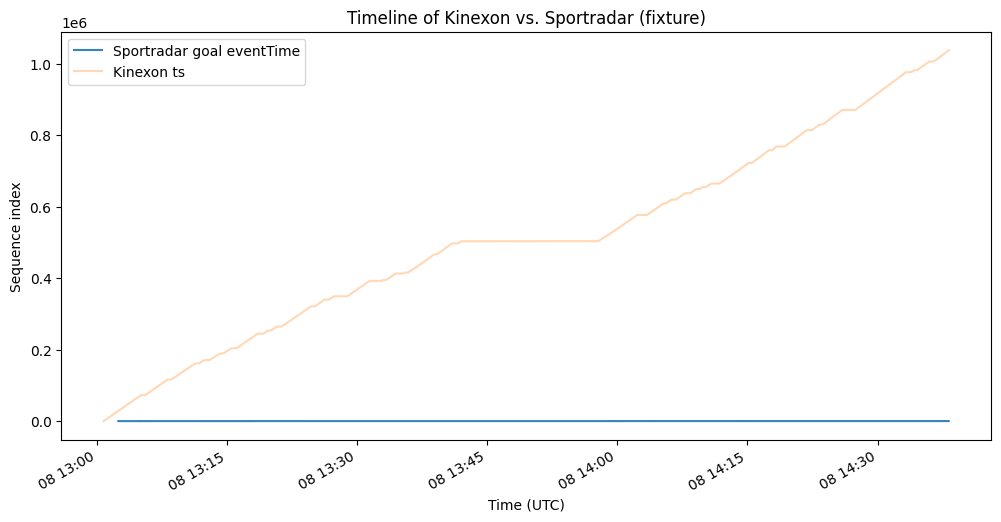

In [9]:
# Cell 8 — Timeline plot (headless-safe)
plt.figure(figsize=(12, 6))
plt.plot(df_goals["eventTime"], np.arange(len(df_goals)), label="Sportradar goal eventTime", alpha=0.9)
plt.plot(df_kinexon_positions["ts"], np.arange(len(df_kinexon_positions)), label="Kinexon ts", alpha=0.3)
plt.xlabel("Time (UTC)")
plt.ylabel("Sequence index")
plt.title("Timeline of Kinexon vs. Sportradar (fixture)")
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()


In [10]:
# Cell 9 — Renderer: draw players, ball, and highlight shooter by league_id match

OUT_DIR = Path("data/metadata")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIELD_IMAGE = Path("data/metadata/handballfeld.png")
if not FIELD_IMAGE.exists():
    # Try parent path as fallback relative to notebook location
    alt = Path("..") / FIELD_IMAGE
    FIELD_IMAGE = alt if alt.exists() else Path("data/metadata/handballfeld.png")

def render_goal_locally(df_kinexon: pd.DataFrame, row_sportradar: pd.Series) -> None:
    """
    Render a visualization of the goal event based on Kinexon data and a Sportradar goal row.
    Highlights the shooter using league_id mapping (already written to players).
    """
    img = cv2.imread(str(FIELD_IMAGE))
    if img is None:
        print(f"⚠️ Could not read field image at: {FIELD_IMAGE}")
        return

    height, width = img.shape[:2]
    scale = width / 40.0  # simple meter->pixel scaling assuming 40m width

    name_event = f'event_{row_sportradar["eventId"]}'
    out_path = OUT_DIR / f"{name_event}.mp4"

    writer = cv2.VideoWriter(
        str(out_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        20,
        (width, height),
    )

    

    # Group frames by time order
    for ts, group in df_kinexon.groupby("ts"):
        img_draw = img.copy()

        for _, r in group.iterrows():
            # group id: 3 = ball? keep color coding
            gid = r.get("group id", None)
            color, radius = (0, 0, 0), 17
            if gid == 3:
                color, radius = (0, 0, 255), 15
            elif gid == 2:
                color, radius = (0, 255, 0), 10
            elif gid == 1:
                color, radius = (255, 0, 0), 10
            
            if pd.isna(r["x in m"]) or pd.isna(r["y in m"]):
                continue
            x = int(float(r["x in m"]) * scale)
            y = int(float(r["y in m"]) * scale)
            cv2.circle(img_draw, (x, y), radius, color, -1)
            # write league id above
            league_id = r.get("league id", "N/A")
            cv2.putText(img_draw, f"ID:{league_id}", (x - 10, y - radius - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            # name above
            name = r.get("full name", "N/A")
            cv2.putText(img_draw, name, (x - 10, y - radius - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            # draw shooter highlight if league id matches
            try:
                shooter_league_id = row_sportradar.get("person_league_id", None)
                if shooter_league_id is not None and int(r.get("league id", -1)) == int(shooter_league_id):
                    cv2.circle(img_draw, (x, y), radius + 5, (255, 255, 0), 2)
            except Exception:
                pass
            # draw goalkeeper highlight if league id matches
            try:
                goalkeeper_league_id = row_sportradar.get("goalkeeper_league_id", None)
                if goalkeeper_league_id is not None and int(r.get("league id", -1)) == int(goalkeeper_league_id):
                    cv2.circle(img_draw, (x, y), radius + 5, (0, 255, 255), 2)
            except Exception:
                pass

            # write game info (name, team, type, time)
            attackType = row_sportradar.get("attackType", "unknown")
            sub_type = row_sportradar.get("subType", "unknown")
            success = row_sportradar.get("success", True)
            name_player = row_sportradar.get("personName", "Unknown Player")
            name_team_player = row_sportradar.get("teamName", "Unknown Team")
            name_goalkeeper = row_sportradar.get("goalkeeperName", "Unknown Goalkeeper")
            id_goalkeeper = row_sportradar.get("goalkeeper_league_id", "N/A")
            cv2.putText(img_draw, f"Player: {name_player} (Team: {name_team_player}) vs. Goalkeeper: {name_goalkeeper} (ID: {id_goalkeeper})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            cv2.putText(img_draw, f"Event: Goal (Type: {attackType}, Sub: {sub_type}), Success: {success} | Time: {ts.strftime('%H:%M:%S')}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            


           
        cv2.imshow("Frame", img_draw)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):  # brief wait to render
            break
        # write frame
        writer.write(cv2.resize(img_draw, (width, height)))

    writer.release()
    print(f"🎬 Saved: {out_path}")


In [11]:
# Cell 10 — Render all goals for the chosen fixture
# Expectation: df_goals rows may include a 'person_league_id' if you joined/added earlier.
# If not present, you can enrich df_goals by joining players to bring league_id:

# extract league id from players by fuzzy matching name, there is no column person_league_id


for _, row in df_goals.iterrows():
    print(f"Rendering goal eventId: {row['eventId']}")
    df_kinexon_scene = df_kinexon_positions[
        (df_kinexon_positions["ts"] >= row["eventTime"] - pd.Timedelta(seconds=15)) &
        (df_kinexon_positions["ts"] <= row["eventTime"] + pd.Timedelta(seconds=0))
    ]
    render_goal_locally(df_kinexon_scene, row)

cv2.destroyAllWindows()


Rendering goal eventId: 905e7280-6de2-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_905e7280-6de2-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: c7b32e60-6de2-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_c7b32e60-6de2-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: e4437f81-6de2-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_e4437f81-6de2-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: e9da77a0-6de2-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_e9da77a0-6de2-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: e9da77a0-6de2-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_e9da77a0-6de2-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: 14bab981-6de3-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_14bab981-6de3-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: 22b6bde0-6de3-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata\event_22b6bde0-6de3-11ef-90d5-e7e599d57524.mp4
Rendering goal eventId: 48557aa1-6de3-11ef-90d5-e7e599d57524
🎬 Saved: data\metadata

KeyboardInterrupt: 

In [ ]:
cv2.destroyAllWindows()

In [ ]:
# Cell 11 — Sanity checks
n_with_league = con.execute("SELECT COUNT(*) AS n FROM players WHERE league_id IS NOT NULL").df()
print("Players with league_id:", int(n_with_league.iloc[0, 0]))

sample_check = con.execute("""
    SELECT me.fixtureId, COUNT(DISTINCT p.personId) AS players_with_league
    FROM match_events me
    JOIN players p ON p.personId = me.personId
    WHERE p.league_id IS NOT NULL
    GROUP BY 1
    ORDER BY players_with_league DESC
    LIMIT 10
""").df()
display(sample_check)


# OLD

In [ ]:
import logging
import csv
from typing import Any, Dict, List
import json
import json
import os
import sys
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
import difflib
import duckdb

In [ ]:
load_dotenv()  # Load environment variables from .env file if present


In [ ]:
# connect duckdb
import duckdb
con = duckdb.connect(database='../data/mydb2024-25.duckdb', read_only=False)

In [ ]:
# print all tables
tables = con.execute("SHOW TABLES").fetchall()
print("Tables in the database:")
for table in tables:
    print(table)

In [ ]:
# display fixtures table with distinct session_id
df_fixtures = con.execute("""
    SELECT 
        fe.*, 
        f.session_id
    FROM fixtures_enhanced AS fe
    LEFT JOIN fixtures AS f
    ON fe.fixtureId = f.fixtureId
""").df()

print("SPORTRADAR: Fixtures data (distinct session_id):")
display(df_fixtures)

# sample fixtureId from fixtures table
sample_fixture_id = df_fixtures['fixtureId'].iloc[0]
# sample session_id from fixtures table where sample_fixture_id matches
sample_session_id = df_fixtures.loc[df_fixtures['fixtureId'] == sample_fixture_id, 'session_id'].iloc[0]
print(f"Sample fixtureId: {sample_fixture_id}, Sample session_id: {sample_session_id}")

# display match_events table with sample fixtureId
df_match_events = con.execute(f"""
    SELECT * FROM match_events 
    WHERE fixtureId = '{sample_fixture_id}'
""").df()
print(f"SPORTRADAR: Match events data for fixtureId {sample_fixture_id}:")
display(df_match_events)

In [ ]:
# find existing session_ids in kinexon_positions
from difflib import get_close_matches


existing_session_ids = con.execute("""
    SELECT DISTINCT session_id, fixture_id FROM kinexon_positions
""").df()
print("Existing session_ids in kinexon_positions:")
display(existing_session_ids)

sample_session_id = existing_session_ids['session_id'].iloc[0]
sample_fixture_id = existing_session_ids['fixture_id'].iloc[0]


# show rows of distinct session_ids in kinexon_positions
df_existing_kinexon = con.execute(f"""
    SELECT * FROM kinexon_positions
    WHERE session_id = {sample_session_id}
""").df()
display(df_existing_kinexon.head())


# show players table: ['dob', 'externalId', 'images', 'nameFamilyLatin', 'nameFamilyLocal', 'nameFullLatin', 'nameFullLocal', 'nameGivenLatin', 'nameGivenLocal', 'nationality', 'personId', 'additionalDetails.height', 'additionalDetails.weight', 'teamName', 'entityId']
df_players = con.execute("SELECT * FROM players").df()
print("SPORTRADAR: Players data:")
display(df_players.head())


# filter df_players for unique players in sample_fixture_id
df_players_in_fixture = con.execute(f"""
    SELECT DISTINCT p.* FROM players AS p
    JOIN match_events AS me
    ON p.personId = me.personId
    WHERE me.fixtureId = '{sample_fixture_id}'
""").df()
print(f"SPORTRADAR: Unique players data for fixtureId {sample_fixture_id}:")
display(df_players_in_fixture)

# Find league id, full name in df_existing_kinexon for sample_session_id
league_kinexon = df_existing_kinexon[df_existing_kinexon['session_id'] == sample_session_id]['league id'].unique()
print(f"KINEXON: League id for session_id {sample_session_id}: {league_kinexon}")
full_names_kinexon = df_existing_kinexon[df_existing_kinexon['session_id'] == sample_session_id]['full name'].unique()
print(f"KINEXON: Full names for session_id {sample_session_id}: {full_names_kinexon}")

# Attempt to match players between SPORTRADAR and KINEXON by exact name matching
matched_players = []
for player_name in df_players_in_fixture['nameFullLatin']:
    if player_name in full_names_kinexon:
        matched_players.append(player_name)
print(f"Number of exactly matched players between SPORTRADAR and KINEXON for fixtureId {sample_fixture_id} and session_id {sample_session_id}: {len(matched_players)}")
print("Exactly matched players:")
for match in matched_players:
    print(match)

# fuzzy matching approach

fuzzy_matched_players = []
for player_name in df_players_in_fixture['nameFullLatin']:
    if player_name not in full_names_kinexon:
        matches = get_close_matches(player_name, full_names_kinexon, n=1, cutoff=0.8)
        if matches:
            fuzzy_matched_players.append((player_name, matches[0]))
print(f"Number of fuzzy matched players between SPORTRADAR and KINEXON for fixtureId {sample_fixture_id} and session_id {sample_session_id}: {len(fuzzy_matched_players)}")
print("Fuzzy matched players (SPORTRADAR name, KINEXON name):")
for match in fuzzy_matched_players:
    print(match)


# show unmatched players in KINEXON
unmatched_players_kinexon = []
for kinexon_name in full_names_kinexon:
    if kinexon_name not in df_players_in_fixture['nameFullLatin'].values:
        unmatched_players_kinexon.append(kinexon_name)
print(f"Number of unmatched players in KINEXON for session_id {sample_session_id}: {len(unmatched_players_kinexon)}")
print("Unmatched players in KINEXON:")
for name in unmatched_players_kinexon:
    print(name)

# # cannot match that way, ne need to do fuzzy matching between df_players_in_fixture["nameFullLatin"] and df_existing_kinexon["player name"]
# from difflib import get_close_matches
# fuzzy_matched_players = []
# for player_name in df_players_in_fixture['nameFullLatin']:
#     name_kin = df_existing_kinexon[df_existing_kinexon['session_id'] == sample_session_id]['full name']
#     print(f"Finding matches for SPORTRADAR player name: {player_name} in KINEXON names: {name_kin.tolist()}")
#     matches = get_close_matches(player_name, name_kin, n=1, cutoff=0.8)
#     if matches:
#         fuzzy_matched_players.append((player_name, matches[0]))
# print(f"Number of fuzzy matched players between SPORTRADAR and KINEXON for fixtureId {sample_fixture_id} and session_id {sample_session_id}: {len(fuzzy_matched_players)}")
# print("Fuzzy matched players (SPORTRADAR name, KINEXON name):")
# for match in fuzzy_matched_players:
#     print(match)


In [ ]:
# session_id of sample_fixture_id
session_id_example = df_fixtures.loc[df_fixtures['fixtureId'] == sample_fixture_id, 'session_id'].values[0]
print(f"Sample session_id for fixtureId {sample_fixture_id}: {session_id_example}")

# show sample of kinexon_positions table
df_kinexon_positions_example = con.execute(f"""
    SELECT * FROM kinexon_positions
    WHERE session_id = {session_id_example}
""").df()
print("SPORTRADAR: Kinexon positions data (sample):")
display(df_kinexon_positions_example.head())


In [ ]:
# Parse time columns (tz-aware, robust to 'Z' and no 'Z')
df_kinexon_positions_example['ts'] = pd.to_datetime(
    df_kinexon_positions_example['ts in ms'], unit='ms', utc=True
)

df_match_events = df_match_events[(df_match_events['class'] == 'sport') & (df_match_events['eventType'] == 'goal')].copy()
df_match_events['eventTime'] = pd.to_datetime(
    df_match_events['eventTime'], utc=True, errors='coerce'
)


# Sort for plotting
df_kinexon_positions_example = df_kinexon_positions_example.sort_values('ts')
df_match_events = df_match_events.sort_values('eventTime')

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Put time on x-axis. Use index/order on y to visualize sequences.
plt.plot(df_match_events['eventTime'], np.arange(len(df_match_events)), label='Sportradar eventTime', alpha=0.8)
# Uncomment if you want to overlay Kinexon points too:
plt.plot(df_kinexon_positions_example['ts'], np.arange(len(df_kinexon_positions_example)), label='Kinexon ts', alpha=0.4)

plt.xlabel('Time (UTC)')
plt.ylabel('Sequence index')
plt.title('Timeline of Kinexon and Sportradar timestamps')
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()


In [ ]:
# # select a fixture with existing entries in kinexon_positions
# session_id_example = df_existing_kinexon['session_id'].iloc[0]
# print(f"Example session_id with existing data: {session_id_example}")

# # find according fixture
# df_fixture_example = df_fixtures[df_fixtures['session_id'] == session_id_example]
# print("Corresponding fixture data:")
# display(df_fixture_example)

# df_events_example = con.execute(f"""
#     SELECT * FROM match_events
#     WHERE session_id = {session_id_example}
# """).df()
# print("Corresponding events data:")
# display(df_events_example)

In [ ]:
import cv2

def render_goal_locally(df_kinexon, row_sportradar):
    """
    Render a visualization of the goal event based on kinexon data and sportradar row.

    Args:
        df_kinexon (pd.DataFrame): Kinexon data containing player positions over time.
        row_sportradar (pd.Series): Sportradar data for a specific event.
    """
    # Check if the event type should be rendered
    img_name = "data/metadata/handballfeld.png"
    img = cv2.imread(img_name)
    if img is None:
        img = cv2.imread("../" + img_name)

    height, width, _ = img.shape
    scale = width / 40

    name_event = f'event_{row_sportradar["eventId"]}'
    writer = cv2.VideoWriter(
        f"data/metadata/{name_event}.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        20,
        (img.shape[1], img.shape[0]),
    )

    df_kinexon["time"] = pd.to_datetime(df_kinexon["ts in ms"], unit="ms", utc=True, errors="coerce")


    df_kinexon_grouped = df_kinexon.groupby("time")

    for ts, group in df_kinexon_grouped:
        img_draw = img.copy()
        img_overlay = np.zeros_like(img_draw)

        
        if pd.isna(row_sportradar["person_league_id"]):
            continue

        for index, row in group.iterrows():
            if row["group id"] != 3:
                if int(row_sportradar["person_league_id"]) == int(row["league id"]):
                    cv2.circle(
                        img_draw,
                        (
                            int(row["x in m"] * scale),
                            int(row["y in m"] * scale),
                        ),
                        17,
                        (0, 0, 0),
                        -1,
                    )
            color, radius = (0, 0, 0), 17
            if row["group id"] == 3:
                color, radius = (0, 0, 255), 15
            elif row["group id"] == 2:
                color, radius = (0, 255, 0), 10
            elif row["group id"] == 1:
                color, radius = (255, 0, 0), 10

            cv2.circle(
                img_draw,
                (int(row["x in m"] * scale), int(row["y in m"] * scale)),
                radius,
                color,
                -1,
            )
            
            # Draw the direction of the player and the ball
            if "direction" in row and not pd.isnull(row["direction"]):
                x_start = int(row["x in m"] * scale)
                y_start = int(row["y in m"] * scale)
                angle = row["direction"]

                # Scale the length of the arrow based on speed
                speed = row.get("speed", 1)  # Default speed to 1 if not available
                max_speed = 10  # Define a max speed for scaling purposes
                min_length = 10  # Minimum length of the arrow
                scaled_length = min_length + (min_length * (speed / max_speed))  # Scale the length, ensuring minimum length of 20

                # Convert angle to radians and calculate dx and dy
                angle_rad = np.deg2rad(angle)
                dx = int(scaled_length * np.cos(angle_rad))
                dy = int(scaled_length * np.sin(angle_rad))

                # Draw the direction arrow
                cv2.arrowedLine(
                    img_draw,
                    (x_start, y_start),
                    (x_start + dx, y_start + dy),
                    (255, 255, 255),
                    2,
                    tipLength=0.3
                )
        # img_draw = plot_text(img_draw, row_sportradar)
        img_draw = cv2.addWeighted(img_draw, 1, img_overlay, 0.5, 0)
        cv2.imshow("Frame", img_draw)
        cv2.waitKey(1)
        # display_image(img_draw, pause_time=0.005)
        img_draw = cv2.resize(img_draw, (width, height))
        writer.write(img_draw)

    writer.release()


# render goals from sample fixture
for index, row in df_match_events.iterrows():
    if row['eventType'] == 'goal':
        print(f"Rendering goal eventId: {row['eventId']}")
        render_goal_locally(df_kinexon_positions_example, row)